In [ ]:
# Transient Synaptic Memory in Random Neuronal Networks
"""
This notebook reproduces the basic dynamical observables presented in the accompanying manuscript.

The notebook reads simulation outputs generated by the C++ implementation and computes

- neuronal activity,
- synaptic activity,
- total synaptic current,
- Jaccard similarity,

followed by visualization of the results.

**Required input files**

- `ActivityInTime.txt`
- `ActiveNodesInTime.txt`
"""

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
############################################################
# Model parameters
############################################################

N = 2000

ETA = 0.02

WE = 1
WI = -4

FONT_SIZE = 14
MARKER_SIZE = 3

NUMBER_OF_INITIAL_ACTIVE_NODES = int(ETA * N)

SAVE_FIGURE = True

FIGURE_NAME = "ActivitySummary.png"

In [8]:
############################################################
# Input files
############################################################

ACTIVITY_FILE = "ActivityInTime.txt"

ACTIVE_NODES_FILE = "ActiveNodesInTime.txt"

In [ ]:
## Simulation outputs
'''
This notebook assumes that the C++ simulation has already been executed.

The following output files must be present in the current directory:

- `ActivityInTime.txt`
- `ActiveNodesInTime.txt`

These files are generated automatically by the C++ implementation.
'''

In [ ]:
############################################################
# Check input files
############################################################

from pathlib import Path

required_files = [
    ACTIVITY_FILE,
    ACTIVE_NODES_FILE
]

missing_files = [
    f for f in required_files
    if not Path(f).exists()
]

if len(missing_files) > 0:

    raise FileNotFoundError(
        "The following required input files were not found:\n\n"
        + "\n".join(missing_files)
    )

print("All required input files were found.")

In [9]:
############################################################
# Load activity
############################################################

data = np.loadtxt(ACTIVITY_FILE)

time = data[:, 0]

rho = data[:, 1]

phi_E = data[:, 2]

phi_I = data[:, 3]

phi_total = phi_E + phi_I

current_total = WE * phi_E + WI * phi_I

In [10]:
############################################################
# Load active neurons
############################################################

data_of_active_nodes_at_t = []

with open(ACTIVE_NODES_FILE) as f:

    for line in f:

        row = np.fromstring(line, sep=" ")

        data_of_active_nodes_at_t.append(row[1:])

In [11]:
############################################################
# Jaccard similarity
############################################################

number_of_sets = len(data_of_active_nodes_at_t)

sets = {

    i: set(data_of_active_nodes_at_t[i])

    for i in range(number_of_sets)

}

base_set = sets[0]

Jaccard = np.zeros(number_of_sets)

for t in range(number_of_sets):

    common = sets[t] & base_set

    union = sets[t] | base_set

    if len(union) != 0:

        Jaccard[t] = len(common) / len(union)

In [ ]:
############################################################
# Plot settings
############################################################

plt.rcParams.update({

    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,

    "axes.titlesize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE - 1,

    "ytick.labelsize": FONT_SIZE - 1,

    "figure.facecolor": "white"

})

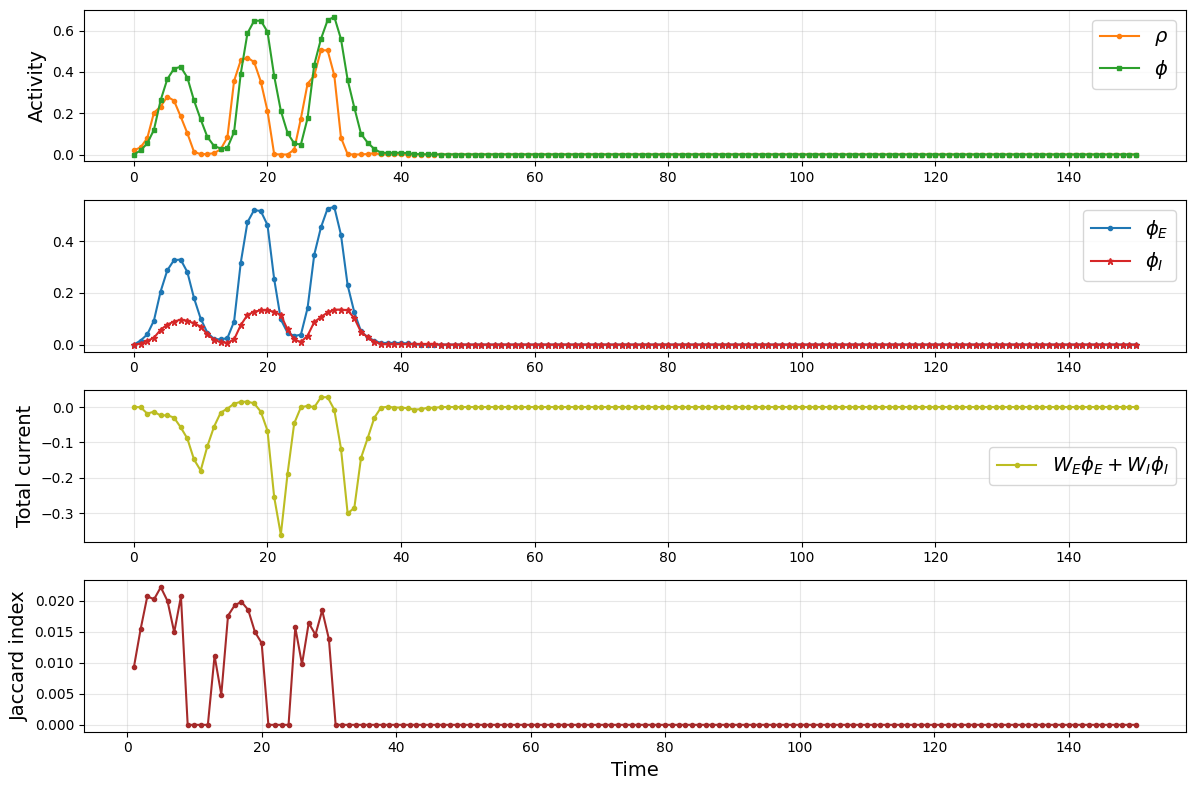

In [13]:
############################################################
# Plot results
############################################################

############################################################
# Create figure
############################################################

fig = plt.figure(
    figsize=(12, 8),
    facecolor="white"
)

############################################################
# Figure 1
# Activity and synaptic activity
############################################################

plt.subplot(4, 1, 1)

plt.plot(
    time,
    rho,
    "-o",
    color="C1",
    ms=MARKER_SIZE,
    label=r"$\rho$"
)

plt.plot(
    time,
    phi_total,
    "-s",
    color="C2",
    ms=MARKER_SIZE,
    label=r"$\phi$"
)

plt.ylabel(
    "Activity",
    fontsize=FONT_SIZE
)

plt.grid(alpha=0.3)

plt.legend(fontsize=FONT_SIZE)

############################################################
# Figure 2
# Excitatory and inhibitory synapses
############################################################

plt.subplot(4, 1, 2)

plt.plot(
    time,
    phi_E,
    "-o",
    color="C0",
    ms=MARKER_SIZE,
    label=r"$\phi_E$"
)

plt.plot(
    time,
    phi_I,
    "-*",
    color="C3",
    ms=MARKER_SIZE + 2,
    label=r"$\phi_I$"
)

plt.grid(alpha=0.3)

plt.legend(fontsize=FONT_SIZE)

############################################################
# Figure 3
# Total synaptic current
############################################################

plt.subplot(4, 1, 3)

plt.plot(
    time,
    current_total,
    "-o",
    color="C8",
    ms=MARKER_SIZE,
    label=r"$W_E\phi_E + W_I\phi_I$"
)

plt.ylabel(
    "Total current",
    fontsize=FONT_SIZE
)

plt.grid(alpha=0.3)

plt.legend(
    fontsize=FONT_SIZE,
    loc="center right"
)

############################################################
# Figure 4
# Jaccard similarity
############################################################

plt.subplot(4, 1, 4)

plt.plot(
    np.arange(1, len(Jaccard)),
    Jaccard[1:],
    "-o",
    color="brown",
    ms=MARKER_SIZE
)

plt.grid(alpha=0.3)

plt.xlabel(
    "Time",
    fontsize=FONT_SIZE
)

plt.ylabel(
    "Jaccard index",
    fontsize=FONT_SIZE
)

plt.tight_layout()

if SAVE_FIGURE:

    plt.savefig(
        FIGURE_NAME,
        dpi=300,
        bbox_inches="tight"
    )

plt.show()